# Chapter 4c -- The greenium

Translated from `HSF/4. ESG Products/*.m` (Roncalli, *Handbook of
Sustainable Finance*): `chap4_greenium1.m` through `greenium6.m`, plus
`greenium3_2023.m` (7 scripts kept; `greenium2_2023.m` and
`greenium6_2023.m` are superseded earlier-vintage duplicates of
`greenium2.m`/`greenium6.m` reproducing the same figures from a smaller
sample and are not built separately).

Continues [`04b_gss_bond_market.ipynb`](04b_gss_bond_market.ipynb) with
the "greenium" -- the yield discount investors accept to hold a green
bond over an otherwise-identical conventional bond -- covering how it's
measured (matched-pair German Bund/Bobl comparisons, duration-matched
interpolation) and its empirical behaviour across a broader corporate
bond panel (time series, cross-sectional stats, currency breakdown).

Two data vintages of matched Bund/Bobl pairs are used side by side, not
because one supersedes the other, but because they capture genuinely
different content: the 2023-vintage data ships each bond's full metric
set (OAS, spread-to-worst, yield-to-worst, effective yield) for one
matched pair, while the 2024-vintage data ships a single precomputed
"greenium" series but across seven matched pairs -- letting section 2
show the metric decomposition and section 3 show the cross-pair
consistency, which no single vintage supports on its own.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"


## 1. Measuring the greenium

Two scripts (`chap4_greenium1.m`, `greenium4.m`) illustrating the
mechanics of a greenium estimate before turning to real data: from a
green/conventional bond price pair via yield-to-maturity, and via
duration-matched interpolation when the two bonds don't share the same
maturity.

### 1.1 From bond prices to a greenium estimate

From `chap4_greenium1.m`. Two hypothetical otherwise-identical 10-year,
4%-coupon bonds priced at 91.35 (green) and 90.07 (conventional); the
greenium is the resulting gap in yield-to-maturity and running yield.

In [2]:

def bond_ytm(t, cashflows, price, tol=1e-10, max_iter=200):
    # Newton's method on the YTM implied by a price and cashflow schedule
    # -- Python equivalent of the toolbox's compute_bond_ytm.m.
    r = 0.05
    for _ in range(max_iter):
        disc = (1 + r) ** t
        pv = np.sum(cashflows / disc)
        dpv = np.sum(-t * cashflows / (1 + r) ** (t + 1))
        r_new = r - (pv - price) / dpv
        if abs(r_new - r) < tol:
            return r_new
        r = r_new
    return r


T, coupon, N = 10, 0.04, 100
t = np.arange(1, T + 1)
cf = coupon * N * np.ones(T)
cf[-1] += N

P1, P2 = 91.35, 90.07
ytm1, ytm2 = bond_ytm(t, cf, P1), bond_ytm(t, cf, P2)
yield1, yield2 = cf[0] / P1, cf[0] / P2

print(f"Green:        price={P1}, YTM={100*ytm1:.3f}%, running yield={100*yield1:.3f}%")
print(f"Conventional: price={P2}, YTM={100*ytm2:.3f}%, running yield={100*yield2:.3f}%")
print(f"Greenium (YTM, running yield), in bps: {1e4*(ytm1-ytm2):.1f}, {1e4*(yield1-yield2):.1f}")


Green:        price=91.35, YTM=5.127%, running yield=4.379%
Conventional: price=90.07, YTM=5.305%, running yield=4.441%
Greenium (YTM, running yield), in bps: -17.8, -6.2


### 1.2 Duration-matched interpolation

From `chap4_greenium4.m`. When the green bond's modified duration
(here $8$) falls between two conventional bonds' durations ($7$ and
$9.5$, yielding $125$ and $148$ bps respectively), the matched
conventional yield is a duration-weighted linear interpolation, and the
greenium is the green bond's yield ($132$ bps) minus that interpolated
benchmark.

In [3]:

MD1, MD_GB, MD2 = 7, 8, 9.5
yield1, yield_gb, yield2 = 125, 132, 148

yield_cb = yield1 + (MD_GB - MD1) / (MD2 - MD1) * (yield2 - yield1)
greenium = yield_gb - yield_cb
print(f"Interpolated conventional yield: {yield_cb:.2f} bps, greenium: {greenium:.2f} bps")


Interpolated conventional yield: 134.20 bps, greenium: -2.20 bps


## 2. A matched Bund/Bobl pair, decomposed by metric

From `chap4_greenium3_2023.m` (data prepared by
`Data/chap4_greenium1_2023.m`). One green German government bond vs. a
maturity-matched conventional Bund, compared across four yield metrics
-- OAS, spread-to-worst, yield-to-worst, and effective yield -- each as
a daily greenium (green minus conventional, bps), September 2020 to
December 2022.

Mean greenium by metric (bps):
OAS               -3.27
Spread to worst   -2.73
Yield to worst    -3.28
Effective yield   -3.27
dtype: float64


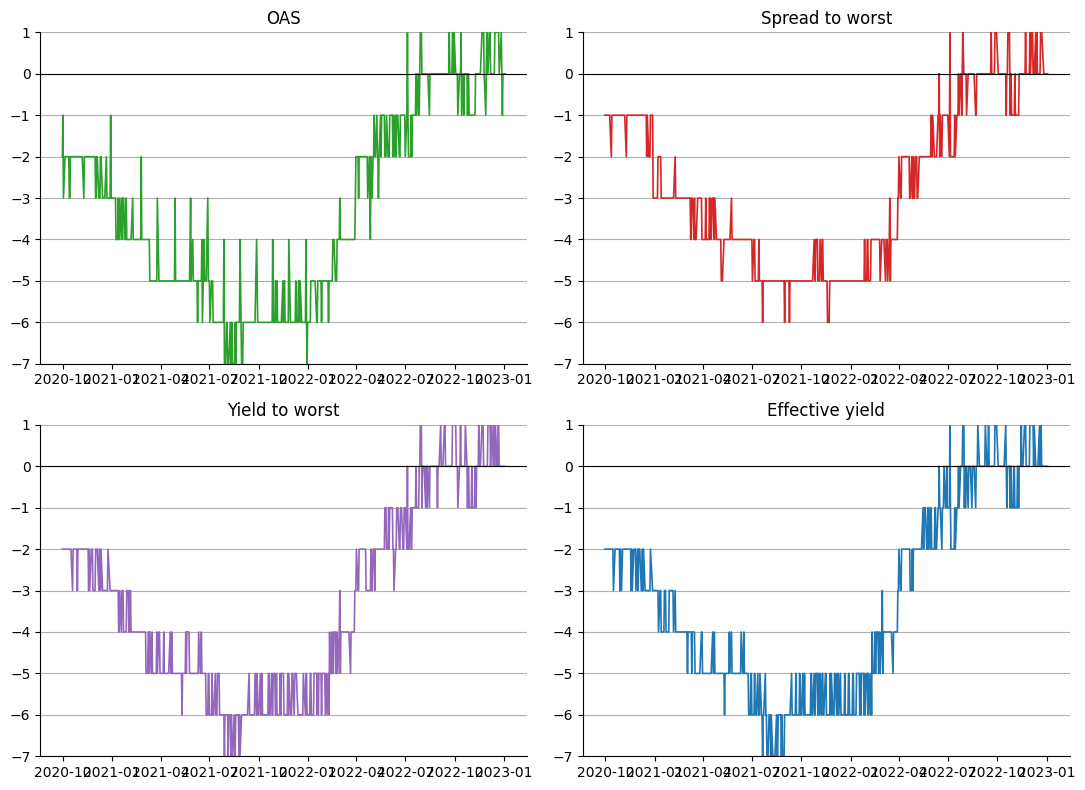

In [4]:

def load_bond_sheet(xlsx_name, sheet):
    df = pd.read_excel(f"{DATA_DIR}/{xlsx_name}", sheet_name=sheet, header=None)
    dates = pd.to_datetime(df.iloc[2:, 2].values)
    cols = df.iloc[2:, [3, 4, 5, 6, 7, 8, 9, 10]].astype(float)
    cols.columns = ["OAS", "Spread_to_Worst", "YTM_sa", "YTM_conv",
                     "YTW_conv", "YTW_sa", "Effective_Yield", "Excess_Return"]
    cols.index = dates
    return cols


green = load_bond_sheet("chap4_greenium1_2023.xlsx", "DE0001030708")
regular = load_bond_sheet("chap4_greenium1_2023.xlsx", "DE0001102507")

# OAS/Spread-to-worst are already quoted in bps in the source; Yield-to-
# worst/Effective-yield are quoted in % -- x100 puts all four on the
# same bps scale for display, matching the source script's own
# (divide-by-100-then-multiply-back) round trip.
metrics = pd.DataFrame({
    "OAS": (green["OAS"] - regular["OAS"]),
    "Spread to worst": (green["Spread_to_Worst"] - regular["Spread_to_Worst"]),
    "Yield to worst": 100 * (green["YTW_conv"] - regular["YTW_conv"]),
    "Effective yield": 100 * (green["Effective_Yield"] - regular["Effective_Yield"]),
}).dropna(how="all")
print("Mean greenium by metric (bps):")
print(metrics.mean().round(2))

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
colors = ["tab:green", "tab:red", "tab:purple", "tab:blue"]
for ax, col, color in zip(axes.flat, metrics.columns, colors):
    ax.plot(metrics.index, metrics[col], color=color, linewidth=1.2)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(col)
    ax.set_ylim(-7, 1)
    ax.grid(axis="y")
plt.tight_layout()
plt.show()


## 3. A single greenium series across seven matched pairs

Two scripts (`chap4_greenium2.m`, `greenium3.m`, data prepared by
`Data/chap4_greenium1_2024.m`) using a precomputed daily "greenium"
field for seven matched German Bund/Bobl pairs, 2020-2024.

### 3.1 The reference pair's greenium over time

From `chap4_greenium2.m`. The `DE0001030708` ("2020 (2030) Bund")
green bond's greenium against its maturity-matched conventional
Bund.

Mean greenium: -3.12 bps


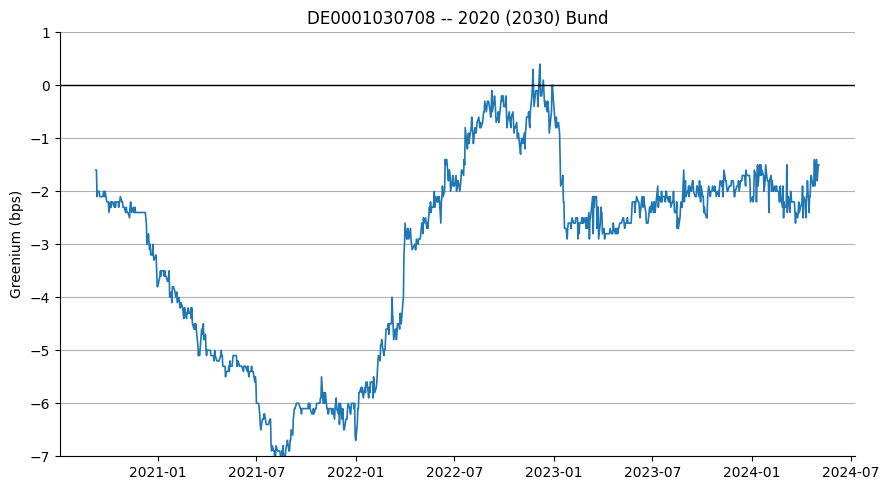

In [5]:

def load_greenium_series(xlsx_name, sheet):
    df = pd.read_excel(f"{DATA_DIR}/{xlsx_name}", sheet_name=sheet, header=0)
    df.columns = ["Date", "Mid_Yield", "Brown_Mid_Yield", "Greenium"]
    return df.set_index("Date")["Greenium"].sort_index()


g1 = load_greenium_series("chap4_greenium1_2024.xlsx", "DE0001030708")
print(f"Mean greenium: {100 * g1.mean():.2f} bps")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(g1.index, 100 * g1, color="tab:blue", linewidth=1.2)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylim(-7, 1)
ax.set_ylabel("Greenium (bps)")
ax.set_title("DE0001030708 -- 2020 (2030) Bund")
ax.grid(axis="y")
plt.tight_layout()
plt.show()


### 3.2 Consistency across matched pairs

From `chap4_greenium3.m`. Scatter of the reference pair's greenium
against three other matched pairs' greenium on the same date --
clustering along the 45-degree line would indicate the greenium is a
broad phenomenon, not an artifact of one bond pair.

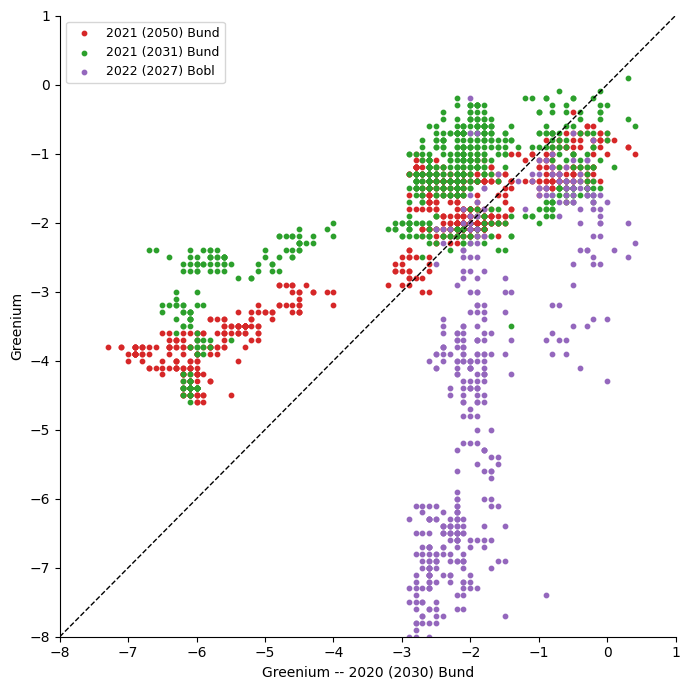

In [6]:

pairs = {
    "2021 (2050) Bund": "DE0001030724",
    "2021 (2031) Bund": "DE0001030732",
    "2022 (2027) Bobl": "DE0001030740",
}
others = {name: load_greenium_series("chap4_greenium1_2024.xlsx", isin) for name, isin in pairs.items()}

fig, ax = plt.subplots(figsize=(7, 7))
colors = ["tab:red", "tab:green", "tab:purple"]
for (name, series), color in zip(others.items(), colors):
    joined = pd.concat([100 * g1, 100 * series], axis=1, join="inner")
    ax.scatter(joined.iloc[:, 0], joined.iloc[:, 1], s=10, color=color, label=name)

ax.plot([-8, 1], [-8, 1], "--", color="black", linewidth=1)
ax.set_xlabel("Greenium -- 2020 (2030) Bund")
ax.set_ylabel("Greenium")
ax.set_xlim(-8, 1)
ax.set_ylim(-8, 1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 4. The greenium across a broader corporate bond panel

Two scripts (`chap4_greenium5.m`, `greenium6.m`, data prepared by
`Data/chap4_greenium2.m`) using a weekly aggregated greenium panel
across a broad corporate green bond universe, split by currency, 2019-2024.

### 4.1 Summary statistics

From `chap4_greenium5.m`. Mean, standard deviation, median, and 2.5th/
97.5th percentiles of the weekly greenium, by currency segment; the
share of EUR-denominated observations at or below -4.5bps and USD-
denominated observations at or above -4.5bps; and the EUR/USD
correlation since 2020.

In [7]:

panel = pd.read_excel(f"{DATA_DIR}/chap4_greenium2.xlsx", sheet_name="Clean", header=0)
panel.columns = ["Date", "AC_Premium", "EUR_Premium", "USD_Premium", "NON_EUR_Premium", "AS_Premium"] + \
    list(panel.columns[6:])
panel["Date"] = pd.to_datetime(panel["Date"])

stats_cols = ["EUR_Premium", "USD_Premium", "AC_Premium"]
stats = panel[stats_cols].agg(["mean", "std", "median",
                                lambda c: c.quantile(0.025), lambda c: c.quantile(0.975)])
stats.index = ["mean", "std", "median", "q2.5%", "q97.5%"]
display(stats.round(1))

p1 = (panel["EUR_Premium"] <= -4.5).mean()
p2 = (panel["USD_Premium"] >= -4.5).mean()
print(f"P(EUR greenium <= -4.5bps) = {100*p1:.2f}%,  P(USD greenium >= -4.5bps) = {100*p2:.2f}%")

recent = panel[panel["Date"].dt.year > 2019]
rho = recent["EUR_Premium"].corr(recent["USD_Premium"])
print(f"EUR/USD correlation (2020+): {100*rho:.1f}%")


,EUR_Premium,USD_Premium,AC_Premium
mean,-2.3,-4.5,-2.7
std,0.9,2.0,0.8
median,-2.2,-4.5,-2.6
q2.5%,-4.3,-7.0,-4.2
q97.5%,-0.7,-1.5,-1.4


P(EUR greenium <= -4.5bps) = 0.81%,  P(USD greenium >= -4.5bps) = 49.39%
EUR/USD correlation (2020+): 17.2%


### 4.2 Weekly greenium by currency segment

From `chap4_greenium6.m`. All-currency, EUR, USD, and non-EUR weekly
greenium, 2019-2024.

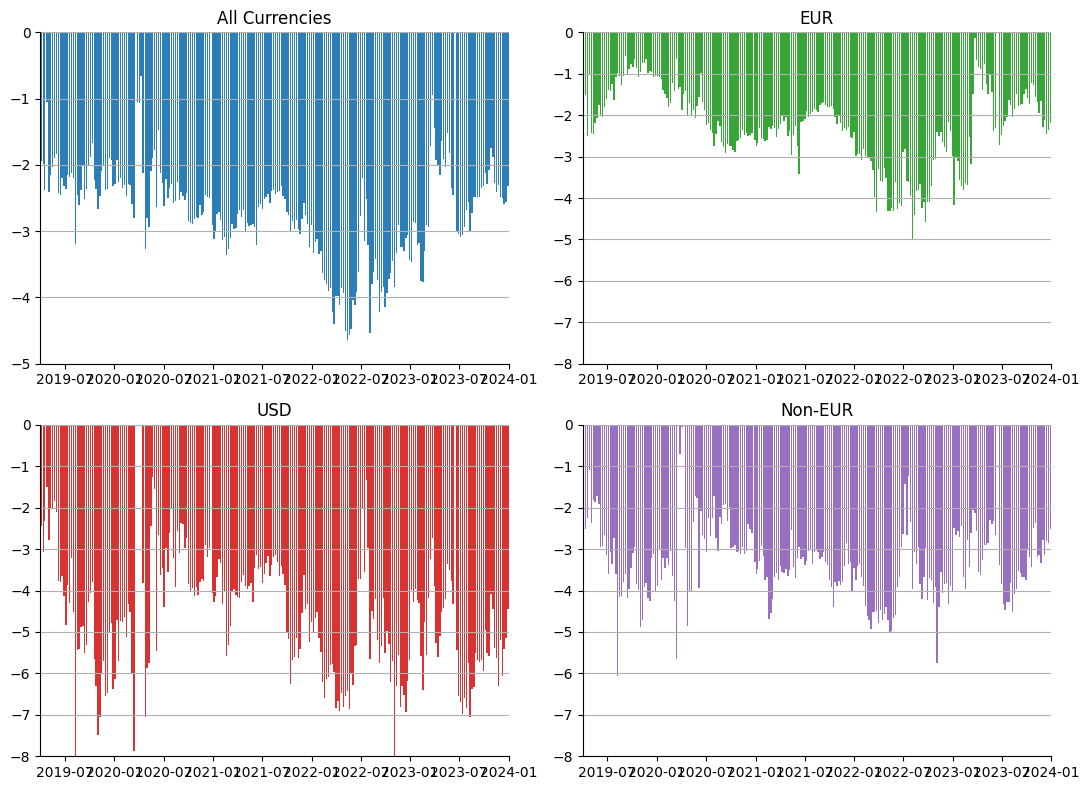

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
segments = [("AC_Premium", "All Currencies", "tab:blue", (-5, 0)),
            ("EUR_Premium", "EUR", "tab:green", (-8, 0)),
            ("USD_Premium", "USD", "tab:red", (-8, 0)),
            ("NON_EUR_Premium", "Non-EUR", "tab:purple", (-8, 0))]

for ax, (col, title, color, ylim) in zip(axes.flat, segments):
    ax.bar(panel["Date"], panel[col], width=5, color=color, alpha=0.95)
    ax.set_title(title)
    ax.set_ylim(*ylim)
    ax.set_xlim(pd.Timestamp("2019-04-01"), pd.Timestamp("2024-01-01"))
    ax.grid(axis="y")

plt.tight_layout()
plt.show()
